# TDCSophiread Tutorial

This notebook demonstrates how to use TDCSophiread for high-performance TPX3 neutron imaging data processing.

## Table of Contents
1. [Installation and Setup](#1-installation-and-setup)
2. [Basic Processing](#2-basic-processing)
3. [Progress Tracking](#3-progress-tracking)
4. [Large File Processing](#4-large-file-processing)
5. [Data Analysis](#5-data-analysis)
6. [Visualization](#6-visualization)
7. [Advanced Usage](#7-advanced-usage)
8. [Performance Benchmarking](#8-performance-benchmarking)

## 1. Installation and Setup

First, import the necessary packages:

In [1]:
import tdcsophiread
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# Check version
print(f"TDCSophiread version: {tdcsophiread.__version__}")
print(f"Available functions: {[x for x in dir(tdcsophiread) if not x.startswith('_')]}")

TDCSophiread version: 2.0.0
Available functions: ['ChipTransform', 'DetectorConfig', 'TDCConfigError', 'TDCFileError', 'TDCHit', 'TDCHitVector', 'TDCProcessingError', 'TDCProcessor', 'TDCStreamProcessor', 'analysis', 'cli', 'config', 'hits_to_numpy', 'process_tpx3', 'process_tpx3_stream']


## 2. Basic Processing

The simplest way to process a TPX3 file:

In [2]:
# Process a TPX3 file
data_file = "../resources/data/tiny.tpx3"

# Simple processing
hits = tdcsophiread.process_tpx3(data_file)

print(f"Processed {len(hits['x']):,} hits")
print(f"Data fields: {list(hits.keys())}")
print(f"\nData types:")
for key, value in hits.items():
    print(f"  {key}: {value.dtype} shape={value.shape}")

Processed 12,969 hits
Data fields: ['x', 'y', 'tof', 'tot', 'chip_id', 'timestamp']

Data types:
  x: uint16 shape=(12969,)
  y: uint16 shape=(12969,)
  tof: uint32 shape=(12969,)
  tot: uint16 shape=(12969,)
  chip_id: uint8 shape=(12969,)
  timestamp: uint32 shape=(12969,)


In [3]:
# Examine the data
stats = tdcsophiread.analysis.calculate_hit_statistics(hits)

print("Hit Statistics:")
print(f"  Total hits: {stats['total_hits']:,}")
print(f"  X range: {stats['coordinate_ranges']['x_range']}")
print(f"  Y range: {stats['coordinate_ranges']['y_range']}")
print(
    f"  TOF range: {stats['timing_stats']['tof_range_ms'][0]:.2f} - {stats['timing_stats']['tof_range_ms'][1]:.2f} ms"
)
print(f"  Active chips: {stats['chip_breakdown']['active_chips']}")
print(f"\nHits per chip:")
for chip, count in stats["chip_breakdown"]["hits_per_chip"].items():
    percentage = stats["chip_breakdown"]["chip_percentages"][chip]
    print(f"    Chip {chip}: {count:,} hits ({percentage:.1f}%)")

Hit Statistics:
  Total hits: 12,969
  X range: (19, 515)
  Y range: (0, 512)
  TOF range: 0.00 - 13.35 ms
  Active chips: [0, 1, 2, 3]

Hits per chip:
    Chip 0: 3,322 hits (25.6%)
    Chip 1: 3,405 hits (26.3%)
    Chip 2: 3,293 hits (25.4%)
    Chip 3: 2,949 hits (22.7%)


## 3. Progress Tracking

For long-running processes, you can track progress:

In [4]:
# Define a progress callback for Jupyter
def jupyter_progress_callback(progress, message):
    clear_output(wait=True)
    bar_length = 50
    filled = int(bar_length * progress)
    bar = "█" * filled + "░" * (bar_length - filled)
    display(f"Progress: [{bar}] {progress:.1%} - {message}")


# Process with progress tracking
print("Processing with progress tracking...")
hits = tdcsophiread.process_tpx3(data_file, progress_callback=jupyter_progress_callback)
print(f"\nCompleted! Processed {len(hits['x']):,} hits")

'Progress: [██████████████████████████████████████████████████] 100.0% - Processing complete'


Completed! Processed 12,969 hits


## 4. Large File Processing

For very large files, use streaming to manage memory:

In [5]:
# Stream processing for large files
chunks = tdcsophiread.process_tpx3_stream(
    data_file,
    chunk_size_mb=1,  # Small chunks for demo
    progress_callback=jupyter_progress_callback,
)

print(f"\nReceived {len(chunks)} chunks")
for i, chunk in enumerate(chunks):
    print(f"  Chunk {i}: {len(chunk['x']):,} hits")

# Combine chunks if needed
all_hits = tdcsophiread.analysis.combine_hit_chunks(chunks)
print(f"\nTotal combined: {len(all_hits['x']):,} hits")

'Progress: [██████████████████████████████████████████████████] 100.0% - Processing complete'


Received 3 chunks
  Chunk 0: 0 hits
  Chunk 1: 0 hits
  Chunk 2: 66 hits

Total combined: 66 hits


## 5. Data Analysis

TDCSophiread includes built-in analysis functions:

In [6]:
# Create TOF spectrum
bin_centers, counts = tdcsophiread.analysis.create_tof_spectrum(
    hits, tof_range_ms=(0, 20), num_bins=200
)

print(f"TOF spectrum: {len(bin_centers)} bins")
print(f"Peak at: {bin_centers[np.argmax(counts)]:.2f} ms with {np.max(counts)} counts")

TOF spectrum: 200 bins
Peak at: 0.85 ms with 278 counts


In [7]:
# Select region of interest (ROI)
roi_hits = tdcsophiread.analysis.select_roi(
    hits, x_range=(100, 400), y_range=(100, 400)
)

print(f"ROI selection:")
print(f"  Original hits: {len(hits['x']):,}")
print(f"  ROI hits: {len(roi_hits['x']):,}")
print(f"  Fraction: {100 * len(roi_hits['x']) / len(hits['x']):.1f}%")

ROI selection:
  Original hits: 12,969
  ROI hits: 4,507
  Fraction: 34.8%


In [8]:
# Filter by time-of-flight
tof_filtered = tdcsophiread.analysis.filter_hits_by_tof(hits, tof_range_ms=(5.0, 15.0))

print(f"TOF filtering (5-15 ms):")
print(f"  Original hits: {len(hits['x']):,}")
print(f"  Filtered hits: {len(tof_filtered['x']):,}")
print(f"  Fraction: {100 * len(tof_filtered['x']) / len(hits['x']):.1f}%")

TOF filtering (5-15 ms):
  Original hits: 12,969
  Filtered hits: 6,474
  Fraction: 49.9%


## 6. Visualization

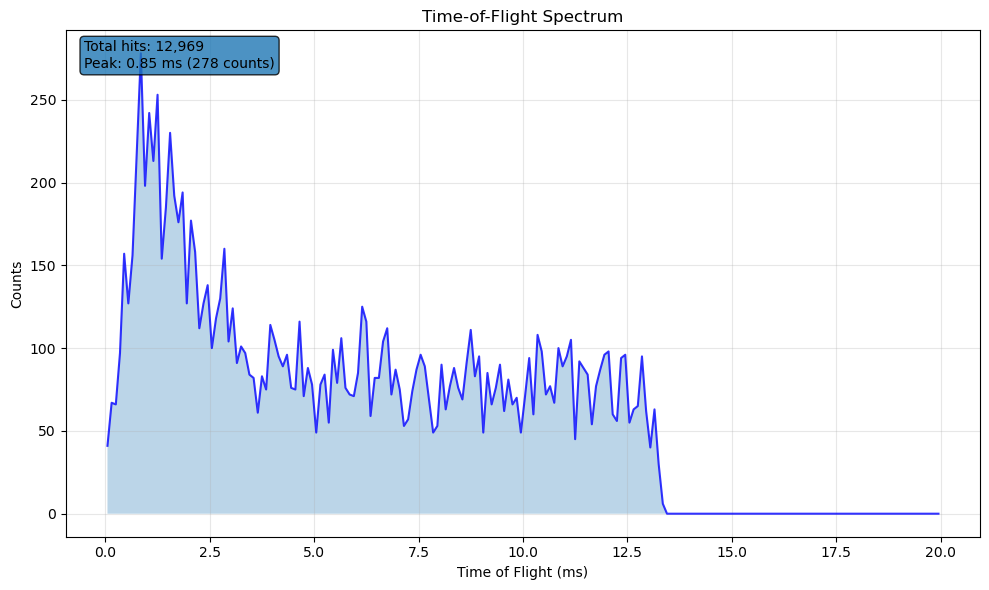

In [9]:
# Plot TOF spectrum
fig = tdcsophiread.analysis.plot_tof_spectrum(
    hits,
    tof_range_ms=(0, 20),
    num_bins=200,
    title="Time-of-Flight Spectrum",
    figsize=(10, 6),
    show_stats=True,
)
plt.show()

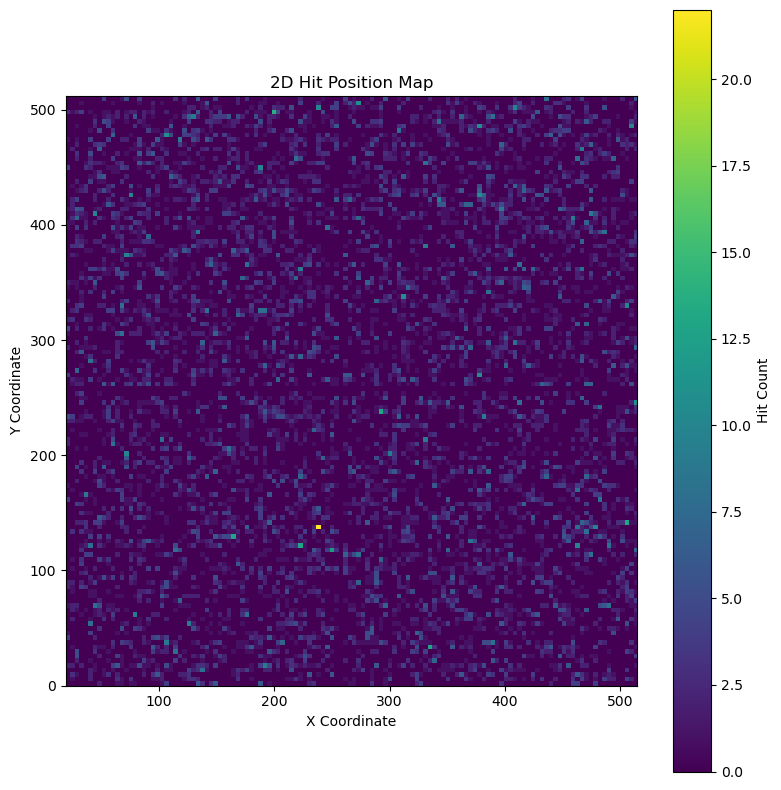

In [10]:
# Plot 2D hit map
fig = tdcsophiread.analysis.plot_hit_map(
    hits, bins=128, title="2D Hit Position Map", figsize=(8, 8), cmap="viridis"
)
plt.show()

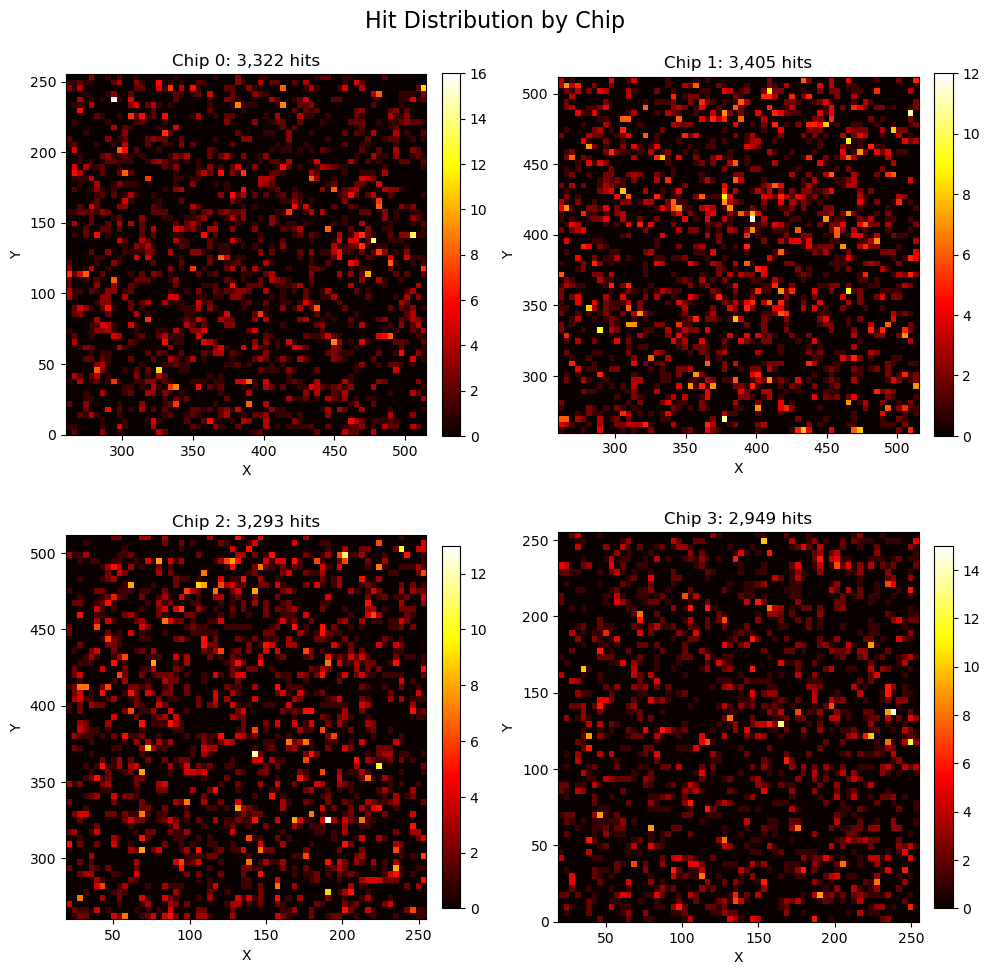

In [11]:
# Custom visualization: Per-chip analysis
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for chip_id in range(4):
    # Filter hits for this chip
    chip_mask = hits["chip_id"] == chip_id
    chip_x = hits["x"][chip_mask]
    chip_y = hits["y"][chip_mask]

    if len(chip_x) > 0:
        h, xedges, yedges = np.histogram2d(chip_x, chip_y, bins=64)
        im = axes[chip_id].imshow(
            h.T,
            origin="lower",
            cmap="hot",
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        )
        axes[chip_id].set_title(f"Chip {chip_id}: {len(chip_x):,} hits")
        axes[chip_id].set_xlabel("X")
        axes[chip_id].set_ylabel("Y")
        plt.colorbar(im, ax=axes[chip_id], fraction=0.046, pad=0.04)
    else:
        axes[chip_id].text(0.5, 0.5, "No data", ha="center", va="center")
        axes[chip_id].set_title(f"Chip {chip_id}: 0 hits")

plt.suptitle("Hit Distribution by Chip", fontsize=16)
plt.tight_layout()
plt.show()

## 7. Advanced Usage

### 7.1 Custom Configuration

In [12]:
# Create custom configuration
config_dict = {
    "detector": {
        "chip_size_x": 512,
        "chip_size_y": 512,
        "num_chips": 4,
        "layout": "2x2",
        "gap_x": 5,  # Custom gap
        "gap_y": 5,
    },
    "timing": {"tdc_frequency": 60.0, "enable_missing_tdc_correction": True},
}

config = tdcsophiread.DetectorConfig.from_json(config_dict)
print(f"TDC frequency: {config.get_tdc_frequency()} Hz")
print(f"Chip size: {config.get_chip_size_x()} x {config.get_chip_size_y()}")

TDC frequency: 60.0 Hz
Chip size: 256 x 256


### 7.2 Direct Processor Usage

In [13]:
# Create processor with custom config
processor = tdcsophiread.TDCProcessor(config)

# Process file
start_time = time.time()
hit_vector = processor.process_file_parallel(data_file, num_threads=4)
process_time = time.time() - start_time

# Convert to numpy
hits = tdcsophiread.hits_to_numpy(hit_vector)

# Get performance metrics
print(f"Processing metrics:")
print(f"  Time: {processor.get_last_processing_time_ms():.1f} ms")
print(f"  Hits: {processor.get_last_hit_count():,}")
print(f"  Packets: {processor.get_last_packet_count():,}")
print(f"  Rate: {processor.get_last_hits_per_second() / 1e6:.1f} M hits/sec")
print(
    f"\nPython overhead: {(process_time - processor.get_last_processing_time_ms() / 1000) * 1000:.1f} ms"
)

Processing metrics:
  Time: 1.0 ms
  Hits: 12,969
  Packets: 306,978
  Rate: 13.4 M hits/sec

Python overhead: 0.1 ms


### 7.3 Context Manager for Streaming

In [14]:
# Use context manager for proper resource management
with tdcsophiread.TDCStreamProcessor(config) as stream_proc:
    chunks = stream_proc.process_file_stream(
        data_file,
        chunk_size_mb=1,
        progress_callback=lambda p, m: print(f"{p:.1%} - {m}"),
    )

    # Process chunks on-the-fly
    total_hits = 0
    for i, chunk in enumerate(chunks):
        chunk_hits = len(chunk["x"])
        total_hits += chunk_hits

        # Could perform analysis on each chunk here
        chunk_stats = tdcsophiread.analysis.calculate_hit_statistics(chunk)
        tof_range_low = (
            chunk_stats["timing_stats"]["tof_range_ms"][0] if chunk_hits > 0 else 0
        )
        tof_range_high = (
            chunk_stats["timing_stats"]["tof_range_ms"][1] if chunk_hits > 0 else 0
        )
        print(
            f"\nChunk {i}: {chunk_hits:,} hits, "
            f"TOF range: {tof_range_low:.2f}-{tof_range_high:.2f} ms"
        )

    print(f"\nTotal hits processed: {total_hits:,}")

0.0% - Starting file processing...
42.6% - Processed 0 hits
85.2% - Processed 0 hits
100.0% - Processed 66 hits
100.0% - Processing complete

Chunk 0: 0 hits, TOF range: 0.00-0.00 ms

Chunk 1: 0 hits, TOF range: 0.00-0.00 ms

Chunk 2: 66 hits, TOF range: 0.00-0.27 ms

Total hits processed: 66


## 8. Performance Benchmarking

In [15]:
# Benchmark different processing modes
import os

file_size_mb = os.path.getsize(data_file) / (1024 * 1024)
print(f"File: {data_file}")
print(f"Size: {file_size_mb:.1f} MB\n")

# Single-threaded
start = time.time()
hits_single = tdcsophiread.process_tpx3(data_file, parallel=False)
time_single = time.time() - start
rate_single = len(hits_single["x"]) / time_single / 1e6

# Multi-threaded
start = time.time()
hits_multi = tdcsophiread.process_tpx3(data_file, parallel=True)
time_multi = time.time() - start
rate_multi = len(hits_multi["x"]) / time_multi / 1e6

# Results
print("Performance Comparison:")
print(f"  Single-threaded: {time_single * 1000:.1f} ms ({rate_single:.1f} M hits/sec)")
print(f"  Multi-threaded:  {time_multi * 1000:.1f} ms ({rate_multi:.1f} M hits/sec)")
print(f"  Speedup: {time_single / time_multi:.1f}x")
print(f"\nThroughput: {file_size_mb / time_multi:.1f} MB/sec")

File: ../resources/data/tiny.tpx3
Size: 2.3 MB

Performance Comparison:
  Single-threaded: 1.3 ms (10.3 M hits/sec)
  Multi-threaded:  1.0 ms (13.4 M hits/sec)
  Speedup: 1.3x

Throughput: 2427.3 MB/sec


In [16]:
# Memory usage comparison
import psutil
import gc

# Get baseline memory
gc.collect()
process = psutil.Process()
baseline_mem = process.memory_info().rss / 1024 / 1024  # MB

# Load all at once
hits_all = tdcsophiread.process_tpx3(data_file)
full_load_mem = process.memory_info().rss / 1024 / 1024
print(f"Full load memory usage: {full_load_mem - baseline_mem:.1f} MB")

# Clear memory
del hits_all
gc.collect()

# Stream processing
max_chunk_mem = baseline_mem
chunks = tdcsophiread.process_tpx3_stream(data_file, chunk_size_mb=1)
for chunk in chunks:
    current_mem = process.memory_info().rss / 1024 / 1024
    max_chunk_mem = max(max_chunk_mem, current_mem)

print(f"Stream peak memory usage: {max_chunk_mem - baseline_mem:.1f} MB")
print(
    f"Memory reduction: {(1 - (max_chunk_mem - baseline_mem) / (full_load_mem - baseline_mem)) * 100:.0f}%"
)

Full load memory usage: 0.3 MB
Stream peak memory usage: 0.4 MB
Memory reduction: -15%


## Summary

This tutorial covered:

1. **Basic Processing**: Simple one-line processing of TPX3 files
2. **Progress Tracking**: Real-time progress updates for long operations
3. **Streaming**: Memory-efficient processing of large files
4. **Analysis**: Built-in functions for TOF spectra, ROI selection, and filtering
5. **Visualization**: Plotting functions for data exploration
6. **Advanced Usage**: Custom configurations and direct processor control
7. **Performance**: Benchmarking and memory optimization

TDCSophiread provides a powerful, user-friendly interface for neutron imaging data processing with excellent performance.